# Minimal Example: Cardiac Phased Array Imaging

Python equivalent of the MATLAB `minimal_example.m`. Downloads a cardiac
phased array dataset, beamforms it with DAS, and displays the scan-converted
B-mode image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys, urllib.request

## Download and read dataset

In [2]:
DATA_URL = "https://www.ustb.no/datasets/"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "data")
filename = "Verasonics_P2-4_parasternal_long_small.uff"
filepath = os.path.join(DATA_PATH, filename)

if not os.path.exists(filepath):
    os.makedirs(DATA_PATH, exist_ok=True)
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(DATA_URL + filename, filepath)

from pyuff_ustb.objects.uff import Uff
channel_data = Uff(filepath).read("channel_data")

print(f"Channel data: {channel_data.N_samples} samples, "
      f"{channel_data.N_channels} channels, "
      f"{channel_data.N_waves} waves, "
      f"{channel_data.N_frames} frames")
print(f"Sound speed: {channel_data.sound_speed} m/s")
print(f"Sampling frequency: {channel_data.sampling_frequency/1e6:.1f} MHz")

Channel data: 2176 samples, 64 channels, 101 waves, 5 frames
Sound speed: 1540.0 m/s
Sampling frequency: 11.9 MHz


## Define sector scan

In [3]:
from pyuff_ustb.objects import SectorScan
from pyuff_ustb.objects.point import Point

sequence = channel_data.sequence
if not isinstance(sequence, (list, tuple)):
    sequence = [sequence]

depth_axis = np.linspace(0e-3, 110e-3, 1024)
azimuth_axis = np.linspace(
    float(sequence[0].source.azimuth),
    float(sequence[-1].source.azimuth),
    len(sequence)
)

scan = SectorScan()
scan.__dict__["azimuth_axis"] = azimuth_axis
scan.__dict__["depth_axis"] = depth_axis
origin = Point()
origin.__dict__["distance"] = 0.0
origin.__dict__["azimuth"] = 0.0
origin.__dict__["elevation"] = 0.0
scan.__dict__["origin"] = origin

print(f"Scan: {len(azimuth_axis)} azimuths × {len(depth_axis)} depths = {len(azimuth_axis)*len(depth_axis)} pixels")

Scan: 101 azimuths × 1024 depths = 103424 pixels


## Beamform with DAS

In [4]:
from ustb.midprocess import DAS
from ustb.enums import Dimension, Window

mid = DAS()
mid.channel_data = channel_data
mid.dimension = Dimension.both
mid.scan = scan
mid.transmit_apodization.window = Window.scanline
mid.receive_apodization.window = Window.none

b_data = mid.go()

USTB Python beamformer...

Completed in 74.81 seconds.


## Display B-mode image

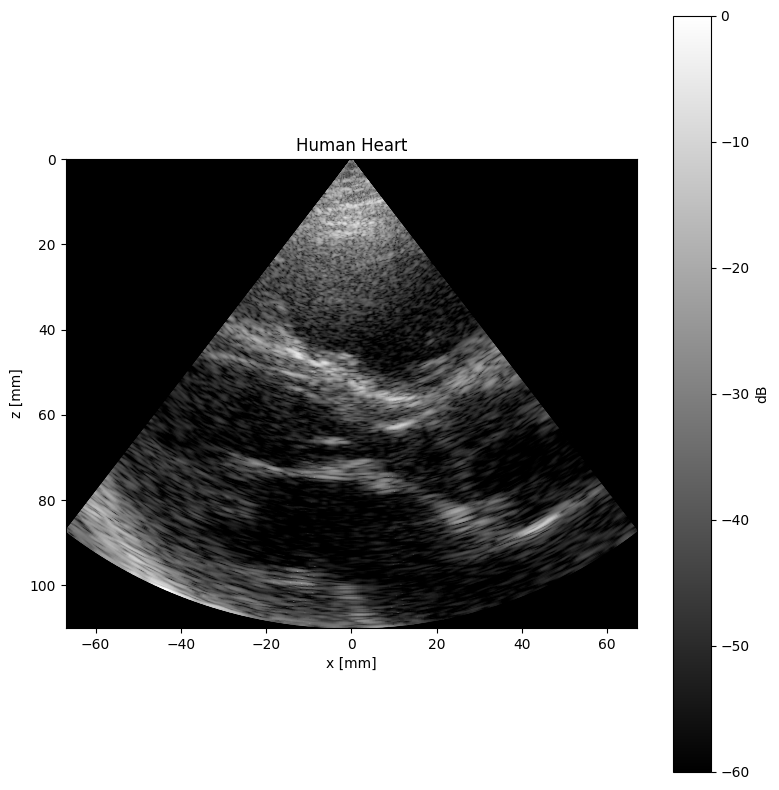

In [5]:
fig, ax = b_data.plot(title="Human Heart", dynamic_range=60)
plt.show()